In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_palette("husl")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
data=pd.read_csv('/content/2016_Building_Energy_Benchmarking.csv')
data.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [ ]:
df=data.copy()

##  Nettoyage initial et filtrage

In [ ]:
# Supprimer les NaN et valeurs ≤ 0
df_clean = df[df['TotalGHGEmissions'].notna() & (df['TotalGHGEmissions'] > 0)].copy()

print(f"Shape après nettoyage: {df_clean.shape}")
print(f"Lignes supprimées: {len(df) - len(df_clean)}")

Shape après nettoyage: (3357, 46)
Lignes supprimées: 19


 ##  Sélection des features

In [ ]:
# Colonnes à exclure
exclude_cols = [
    'OSEBuildingID', 'DataYear', 'PropertyName', 'Address', 'City', 'State', 'ZipCode',
    'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Comments', 'ComplianceStatus',
    'TotalGHGEmissions',  # Cible
    'GHGEmissionsIntensity', 'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)',
    'SiteEUI(kBtu/sf)', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)'
]

# Features disponibles
features = [col for col in df_clean.columns if col not in exclude_cols]

print(f"\nFeatures disponibles: {len(features)}")
print(features[:20])


Features disponibles: 27
['BuildingType', 'PrimaryPropertyType', 'Neighborhood', 'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified', 'ENERGYSTARScore']


In [ ]:
numeric_features = df_clean[features].select_dtypes(include=np.number).columns.tolist()
categorical_features = df_clean[features].select_dtypes(include='object').columns.tolist()

print(f"\n{len(numeric_features)} numériques, {len(categorical_features)} catégorielles")
print(f"Numériques: {numeric_features}")
print(f"Catégorielles: {categorical_features}")


17 numériques, 9 catégorielles
Numériques: ['Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'ThirdLargestPropertyUseTypeGFA', 'ENERGYSTARScore', 'SteamUse(kBtu)', 'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)', 'NaturalGas(kBtu)']
Catégorielles: ['BuildingType', 'PrimaryPropertyType', 'Neighborhood', 'ListOfAllPropertyUseTypes', 'LargestPropertyUseType', 'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType', 'YearsENERGYSTARCertified', 'Outlier']


##  Feature Engineering

In [ ]:
# Âge du bâtiment
df_clean['BuildingAge'] = 2016 - df_clean['YearBuilt']

# Ratios par surface
df_clean['SteamUsePerSqFt'] = df_clean['SteamUse(kBtu)'] / (df_clean['PropertyGFATotal'] + 1)
df_clean['ElectricityPerSqFt'] = df_clean['Electricity(kBtu)'] / (df_clean['PropertyGFATotal'] + 1)
df_clean['NaturalGasPerSqFt'] = df_clean['NaturalGas(kBtu)'] / (df_clean['PropertyGFATotal'] + 1)

# Énergie totale
df_clean['TotalEnergy'] = df_clean[['SteamUse(kBtu)', 'Electricity(kBtu)', 'NaturalGas(kBtu)']].sum(axis=1)

# Mettre à jour la liste des features numériques
numeric_features.extend(['BuildingAge', 'SteamUsePerSqFt', 'ElectricityPerSqFt',
                        'NaturalGasPerSqFt', 'TotalEnergy'])

print(f"\nFeatures créées: 5 nouvelles features")
print(f"Total features numériques: {len(numeric_features)}")


Features créées: 5 nouvelles features
Total features numériques: 22


## Transformation log de la cible

In [ ]:
df_clean['TotalGHGEmissions_log'] = np.log1p(df_clean['TotalGHGEmissions'])

skew_original = stats.skew(df_clean['TotalGHGEmissions'])
skew_log = stats.skew(df_clean['TotalGHGEmissions_log'])

print(f"Skewness original: {skew_original:.2f}")
print(f"Skewness log: {skew_log:.2f}")

Skewness original: 19.45
Skewness log: 0.38


##  Split Train/Test

In [ ]:
X = df_clean[numeric_features + categorical_features].copy()
y = df_clean['TotalGHGEmissions_log'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (2685, 31) | Test: (672, 31)


##  Pipeline de preprocessing

In [ ]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

##  Entraînement des modèles

### 1. Baseline: Régression linéaire

In [ ]:
model_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model_lr.fit(X_train, y_train)

y_train_pred_lr = model_lr.predict(X_train)
y_test_pred_lr = model_lr.predict(X_test)

metrics_lr_train = evaluate(y_train, y_train_pred_lr, "Train")
metrics_lr_test = evaluate(y_test, y_test_pred_lr, "Test")


Train:
  MAE: 152
  RMSE: 1,936
  R²: -9.689

Test:
  MAE: 481
  RMSE: 4,451
  R²: -369.058


### 2. Ridge Regression

In [ ]:
def evaluate(y_true, y_pred, name):
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred)

    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2 = r2_score(y_true_orig, y_pred_orig)

    print(f"\n{name}:")
    print(f"  MAE: {mae:,.0f}")
    print(f"  RMSE: {rmse:,.0f}")
    print(f"  R²: {r2:.3f}")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

model_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

model_ridge.fit(X_train, y_train)

metrics_ridge_train = evaluate(y_train, model_ridge.predict(X_train), "Train - Ridge")
metrics_ridge_test = evaluate(y_test, model_ridge.predict(X_test), "Test - Ridge")


Train - Ridge:
  MAE: 249
  RMSE: 4,238
  R²: -50.244

Test - Ridge:
  MAE: 267
  RMSE: 2,216
  R²: -90.710


### 3. Random Forest Regressor

In [ ]:
model_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

model_rf.fit(X_train, y_train)

metrics_rf_train = evaluate(y_train, model_rf.predict(X_train), "Train - Random Forest")
metrics_rf_test = evaluate(y_test, model_rf.predict(X_test), "Test - Random Forest")


Train - Random Forest:
  MAE: 10
  RMSE: 169
  R²: 0.918

Test - Random Forest:
  MAE: 11
  RMSE: 77
  R²: 0.888


### 4. Gradient Boosting Regressor


In [ ]:
model_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=RANDOM_STATE
    ))
])

model_gb.fit(X_train, y_train)

metrics_gb_train = evaluate(y_train, model_gb.predict(X_train), "Train - GB")
y_test_pred_gb = model_gb.predict(X_test)
metrics_gb_test = evaluate(y_test, y_test_pred_gb, "Test - GB")


Train - GB:
  MAE: 2
  RMSE: 10
  R²: 1.000

Test - GB:
  MAE: 12
  RMSE: 90
  R²: 0.848


##  Comparaison des modèles

In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Random Forest', 'Gradient Boosting'],
    'Train_MAE': [metrics_lr_train['MAE'], metrics_ridge_train['MAE'],
                  metrics_rf_train['MAE'], metrics_gb_train['MAE']],
    'Test_MAE': [metrics_lr_test['MAE'], metrics_ridge_test['MAE'],
                 metrics_rf_test['MAE'], metrics_gb_test['MAE']],
    'Train_RMSE': [metrics_lr_train['RMSE'], metrics_ridge_train['RMSE'],
                   metrics_rf_train['RMSE'], metrics_gb_train['RMSE']],
    'Test_RMSE': [metrics_lr_test['RMSE'], metrics_ridge_test['RMSE'],
                  metrics_rf_test['RMSE'], metrics_gb_test['RMSE']],
    'Train_R2': [metrics_lr_train['R2'], metrics_ridge_train['R2'],
                 metrics_rf_train['R2'], metrics_gb_train['R2']],
    'Test_R2': [metrics_lr_test['R2'], metrics_ridge_test['R2'],
                metrics_rf_test['R2'], metrics_gb_test['R2']]
})

print(results.to_string(index=False))
print(f"\nMeilleur: {results.loc[results['Test_R2'].idxmax(), 'Model']}")

            Model  Train_MAE   Test_MAE  Train_RMSE   Test_RMSE   Train_R2     Test_R2
Linear Regression 151.670400 480.984811 1935.592677 4450.825397  -9.688814 -369.058192
            Ridge 249.076474 266.500614 4238.109235 2215.713720 -50.244334  -90.709896
    Random Forest  10.042748  10.979432  169.094605   77.328263   0.918424    0.888297
Gradient Boosting   1.854882  11.637188   10.231700   90.068431   0.999701    0.848458

Meilleur: Random Forest


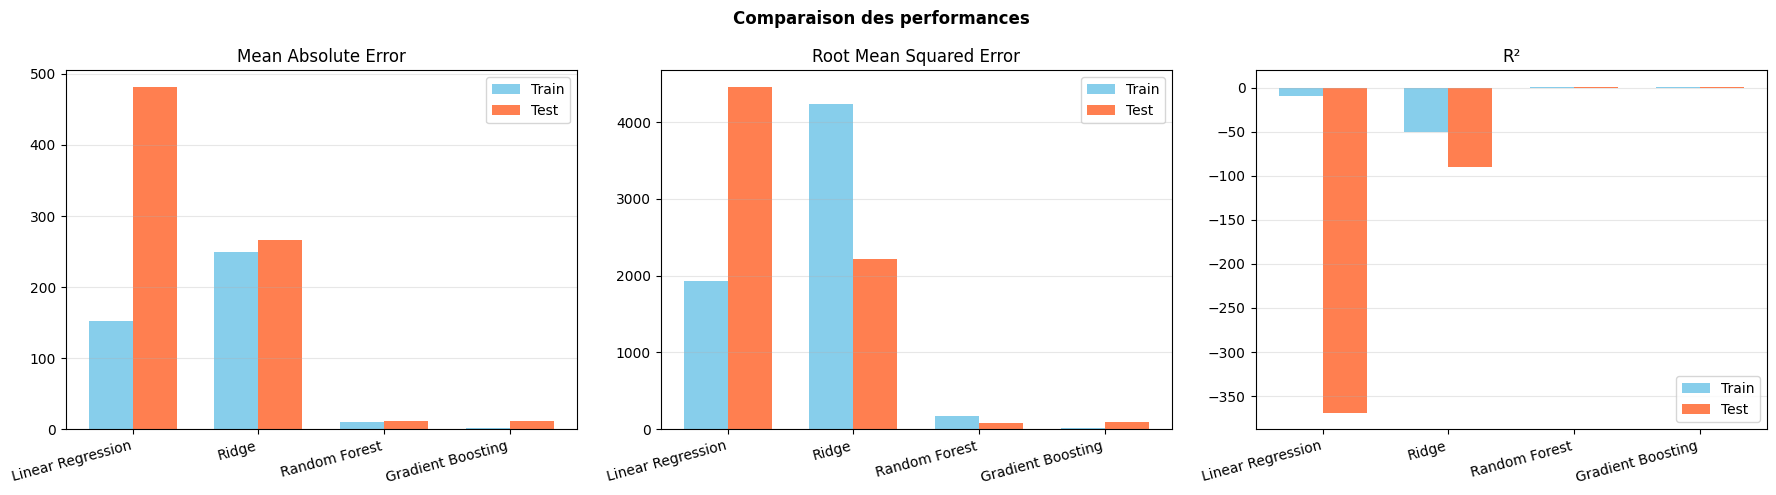

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['MAE', 'RMSE', 'R2']
titles = ['Mean Absolute Error', 'Root Mean Squared Error', 'R²']

x = np.arange(len(results))
width = 0.35

for i, (metric, title) in enumerate(zip(metrics, titles)):
    axes[i].bar(x - width/2, results[f'Train_{metric}'], width, label='Train', color='skyblue')
    axes[i].bar(x + width/2, results[f'Test_{metric}'], width, label='Test', color='coral')
    axes[i].set_title(title)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(results['Model'], rotation=15, ha='right')
    axes[i].legend()
    axes[i].grid(alpha=0.3, axis='y')

plt.suptitle('Comparaison des performances', fontweight='bold')
plt.tight_layout()
plt.show()

## Validation croisée

In [ ]:
models = {
    'Linear Regression': model_lr,
    'Ridge': model_ridge,
    'Random Forest': model_rf,
    'Gradient Boosting': model_gb
}

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=kfold,
                            scoring='neg_mean_squared_error', n_jobs=-1)
    rmse = np.sqrt(-scores).mean()
    print(f"{name}: {rmse:,.0f}")

Linear Regression: 1
Ridge: 1
Random Forest: 0
Gradient Boosting: 0


## Analyse des résidus (meilleur modèle)

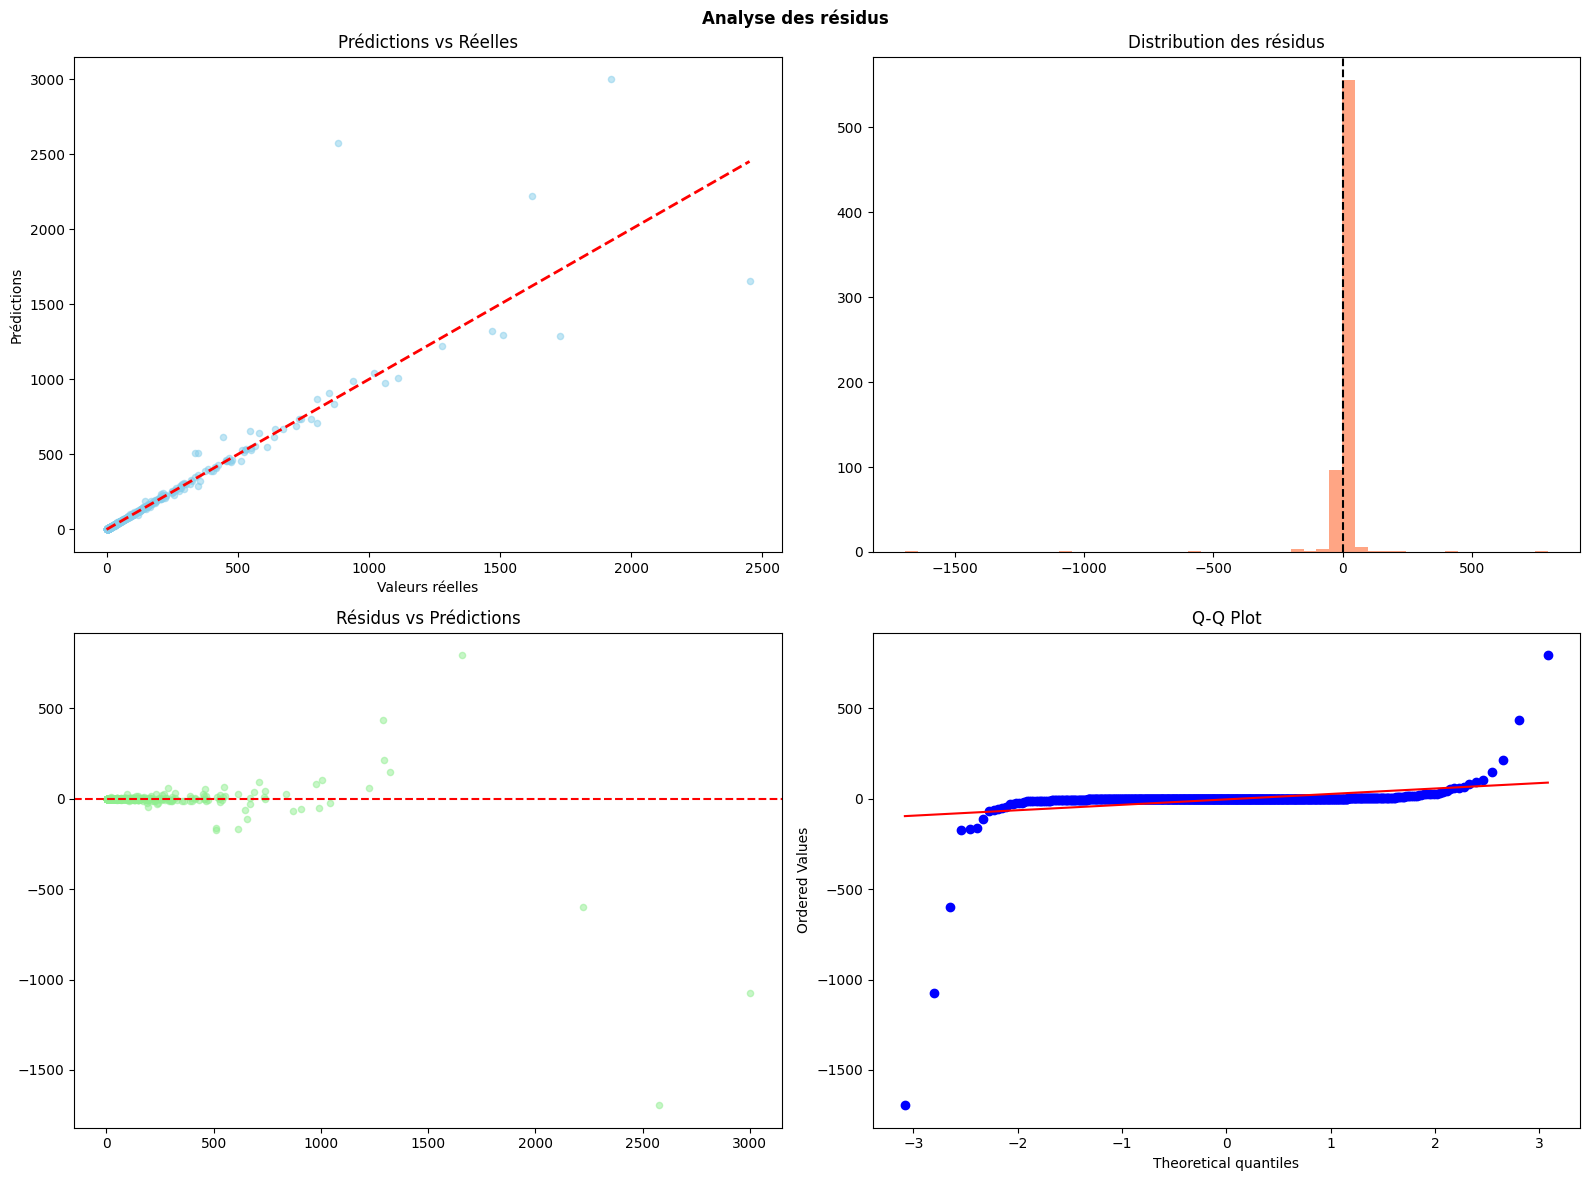


Résidus - Moyenne: -3 | Std: 90


In [ ]:
# Reconvertir en échelle originale
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_test_pred_gb)
residuals = y_test_orig - y_pred_orig

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Predicted vs Actual
axes[0, 0].scatter(y_test_orig, y_pred_orig, alpha=0.5, s=20, color='skyblue')
axes[0, 0].plot([y_test_orig.min(), y_test_orig.max()],
                [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
axes[0, 0].set_title('Prédictions vs Réelles')
axes[0, 0].set_xlabel('Valeurs réelles')
axes[0, 0].set_ylabel('Prédictions')

# Distribution des résidus
axes[0, 1].hist(residuals, bins=50, alpha=0.7, color='coral')
axes[0, 1].axvline(0, color='black', linestyle='--')
axes[0, 1].set_title('Distribution des résidus')

# Résidus vs Prédictions
axes[1, 0].scatter(y_pred_orig, residuals, alpha=0.5, s=20, color='lightgreen')
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('Résidus vs Prédictions')

# Q-Q plot
from scipy.stats import probplot
probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.suptitle('Analyse des résidus', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRésidus - Moyenne: {residuals.mean():,.0f} | Std: {residuals.std():,.0f}")